# Model Comparison


## Analysis Multivariate vs Univariate

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Import all_results.parquet file
df_results = pd.read_parquet("all_results.parquet")

#sort model for better visualization
model_order = ["MLP", "RNN", "LSTM", "GRU", "Transformer", "CNN1D", "NBEATS", "NBEATSx"]
df_results["Model"] = pd.Categorical(df_results["Model"], categories=model_order, ordered=True)

### Univariate Models

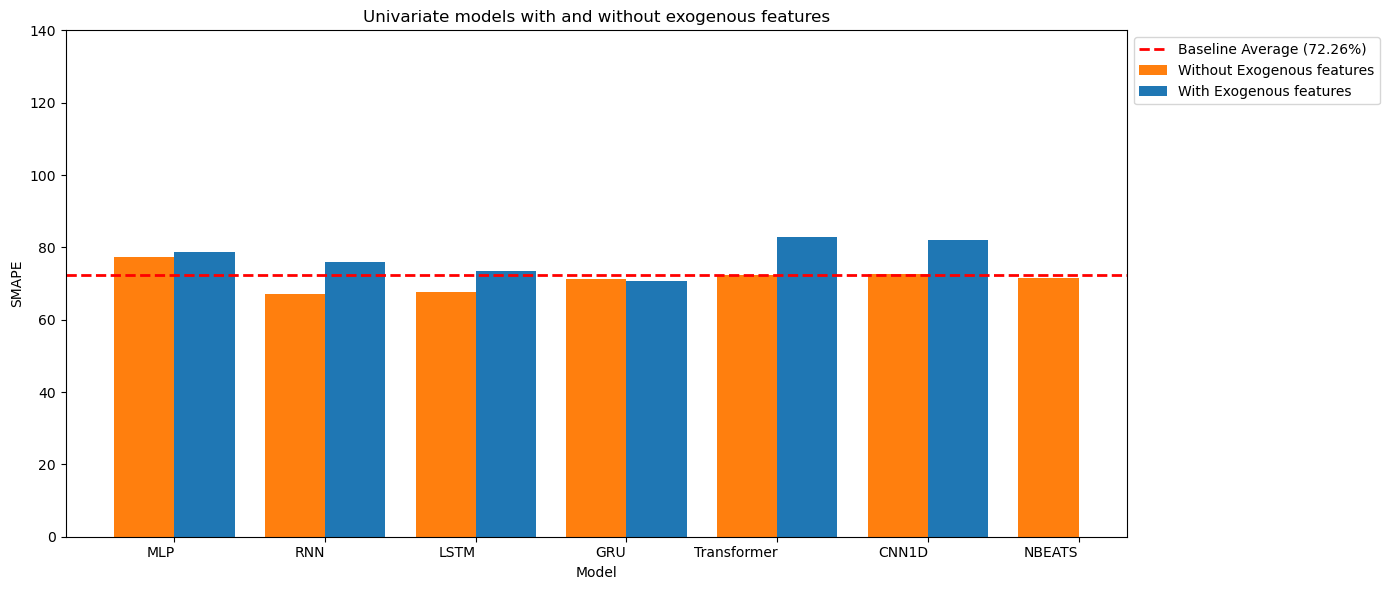

In [54]:


df_plot_uni = df_results[(df_results["Fold"]=="Average") & (df_results["Approach"]=="Uni")].copy()

pivot = df_plot_uni.pivot_table(index="Model", columns="Features", values="SMAPE", aggfunc="mean", observed=True)

models = pivot.index.tolist()
x = np.arange(len(models))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, pivot["noExog"], width, label="Without Exogenous features", color="#ff7f0e" )
plt.bar(x + width/2, pivot["Exog"],   width, label="With Exogenous features",   color="#1f77b4")

plt.axhline(y=72.26, linestyle="--", label="Baseline Average (72.26%)", linewidth=2, color="red")

plt.title("Univariate models with and without exogenous features")
plt.xticks(x, models, rotation=0, ha="right")
plt.xlabel("Model")
plt.ylabel("SMAPE")
#legend outside the plot

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
#y-axis limit for better comparison
plt.ylim(0, 140)
plt.tight_layout()
plt.show()

### Multivariate Models

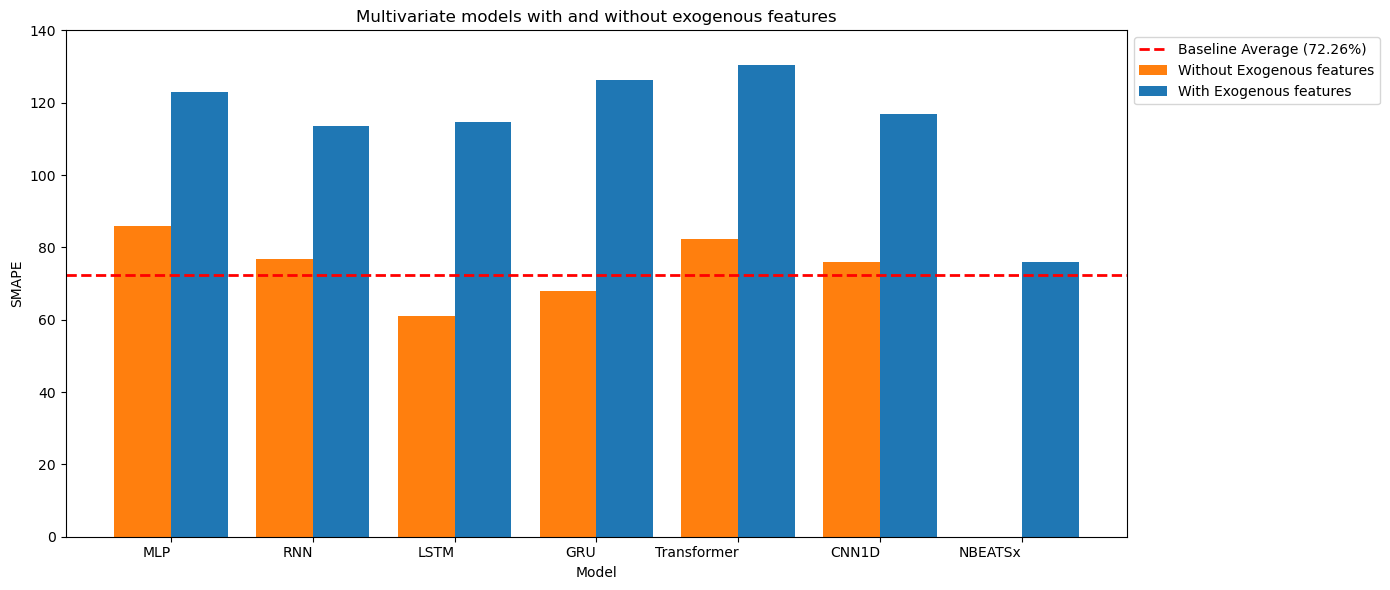

In [55]:


df_plot_multi = df_results[(df_results["Fold"]=="Average") & (df_results["Approach"]=="Multi")].copy()


pivot = df_plot_multi.pivot_table(index="Model", columns="Features", values="SMAPE", aggfunc="mean", observed=True)

models = pivot.index.tolist()
x = np.arange(len(models))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, pivot["noExog"], width, label="Without Exogenous features", color="#ff7f0e" )
plt.bar(x + width/2, pivot["Exog"],   width, label="With Exogenous features",   color="#1f77b4")

plt.axhline(y=72.26, linestyle="--", label="Baseline Average (72.26%)", linewidth=2, color="red")

plt.title("Multivariate models with and without exogenous features")
plt.xticks(x, models, rotation=0, ha="right")
plt.xlabel("Model")
plt.ylabel("SMAPE")
#legend outside the plot

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

#y-axis limit for better comparison
plt.ylim(0, 140)
plt.tight_layout()
plt.show()